# Customer Segmentation & Revenue Analytics

## Objective
Analyze e-commerce transaction data to:
- Evaluate revenue performance
- Segment customers using RFM
- Identify high-value customer groups
- Analyze retention using cohort analysis

## Dataset Overview

The dataset includes:
- Customers
- Orders
- Order Items
- Payments
- Products

Source: Olist Brazilian E-commerce Dataset

## Importing dependencies


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

Loaded five relational datasets:
- Customers
- Orders
- Order Items
- Payments
- Products

## Reading Csv files

In [2]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')


In [3]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')


In [4]:
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')


In [5]:
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')


In [6]:
products = pd.read_csv('../data/olist_products_dataset.csv')


In [7]:
print("Customers:", customers.shape)


Customers: (99441, 5)


In [8]:
print("Products:", products.shape)


Products: (32951, 9)


In [9]:
print("Payments:", payments.shape)


Payments: (103886, 5)


In [10]:
print("Orders:", orders.shape)


Orders: (99441, 8)


In [11]:
print("Order Items:", order_items.shape)


Order Items: (112650, 7)


In [12]:
 orders['order_purchase_timestamp']

0        2017-10-02 10:56:33
1        2018-07-24 20:41:37
2        2018-08-08 08:38:49
3        2017-11-18 19:28:06
4        2018-02-13 21:18:39
                ...         
99436    2017-03-09 09:54:05
99437    2018-02-06 12:58:58
99438    2017-08-27 14:46:43
99439    2018-01-08 21:28:27
99440    2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 99441, dtype: object

## Data Cleaning & Preprocessing

Steps performed:
- Converted date columns to datetime
- Filtered only delivered orders
- Removed null payment records
- Created delivery time feature

In [13]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [14]:
orders['order_purchase_timestamp']

0       2017-10-02 10:56:33
1       2018-07-24 20:41:37
2       2018-08-08 08:38:49
3       2017-11-18 19:28:06
4       2018-02-13 21:18:39
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 12:58:58
99438   2017-08-27 14:46:43
99439   2018-01-08 21:28:27
99440   2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 99441, dtype: datetime64[ns]

In [15]:
print("Start Date:", orders['order_purchase_timestamp'].min())


Start Date: 2016-09-04 21:15:19


In [16]:
print("End Date:", orders['order_purchase_timestamp'].max())


End Date: 2018-10-17 17:30:18


In [17]:
customers.isnull().sum()


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [18]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [19]:
orders['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [20]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [21]:
orders.describe()


,order_purchase_timestamp
count,99441
mean,2017-12-31 08:43:12.776581120
min,2016-09-04 21:15:19
25%,2017-09-12 14:46:19
50%,2018-01-18 23:04:36
75%,2018-05-04 15:42:16
max,2018-10-17 17:30:18


In [22]:
orders.isnull().sum()



order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [23]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

In [24]:
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [25]:
orders['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [26]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()


In [27]:
orders_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [28]:
orders_clean['order_delivered_customer_date'].isna().sum()


8

In [29]:
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date']).copy()


In [30]:
orders_clean.duplicated().sum()


0

In [31]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [32]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [33]:
orders_clean

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [34]:
revenue_df = orders_clean.merge(
    payments,
    on='order_id',
    how='left'
)

In [35]:
revenue_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...
100744,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1.0,credit_card,3.0,85.08
100745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,credit_card,3.0,195.00
100746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,credit_card,5.0,271.01
100747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1.0,credit_card,4.0,441.16


In [36]:
revenue_df.shape

(100749, 12)

In [37]:
revenue_df.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
payment_sequential                1
payment_type                      1
payment_installments              1
payment_value                     1
dtype: int64

In [38]:
revenue_df[revenue_df['payment_value'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
31173,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,NaN,NaN,NaN,NaN


In [39]:
revenue_df = revenue_df.dropna(subset=['payment_value']).copy()

In [40]:
revenue_df.isna().sum()    

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
payment_sequential                0
payment_type                      0
payment_installments              0
payment_value                     0
dtype: int64

## Revenue & KPI Analysis

Calculated core business KPIs:
- Total Revenue
- Total Orders
- Average Order Value (AOV)
- Average Delivery Time

In [41]:
total_revenue = revenue_df['payment_value'].sum()

In [42]:
total_revenue

15421082.85

In [43]:
revenue_df['order_id'].nunique()

96469

In [44]:
orders_clean['order_id'].nunique()

96470

In [45]:
revenue_df['year'] = revenue_df['order_purchase_timestamp'].dt.year



In [46]:
orders_clean['order_approved_at']

0       2017-10-02 11:07:15
1       2018-07-26 03:24:27
2       2018-08-08 08:55:23
3       2017-11-18 19:45:59
4       2018-02-13 22:20:29
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 13:10:37
99438   2017-08-27 15:04:16
99439   2018-01-08 21:36:21
99440   2018-03-09 11:20:28
Name: order_approved_at, Length: 96470, dtype: datetime64[ns]

In [47]:
revenue_df['year'] 

0         2017
1         2017
2         2017
3         2018
4         2018
          ... 
100744    2017
100745    2018
100746    2017
100747    2018
100748    2018
Name: year, Length: 100748, dtype: int32

In [48]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [49]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [50]:
order_items['item_revenue'] = order_items['price'] + order_items['freight_value']

In [51]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [52]:
order_revenue = order_items.groupby('order_id')['item_revenue'].sum().reset_index()

In [53]:
order_revenue

,order_id,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,343.40
98662,fffcd46ef2263f404302a634eb57f7eb,386.53
98663,fffce4705a9662cd70adb13d4a31832d,116.85
98664,fffe18544ffabc95dfada21779c9644f,64.71


In [54]:
orders_final = orders_clean.merge(order_revenue, on='order_id', how='inner')

In [55]:
orders_final.shape

(96470, 9)

In [56]:
orders_final['item_revenue'].isnull().sum()

0

In [57]:
total_revenue

15421082.85

In [58]:
total_orders = orders_final['order_id'].nunique()


In [59]:
total_orders

96470

In [60]:
aov = total_revenue / total_orders


In [61]:
aov

159.85366279672436

In [62]:
orders_final['item_revenue'].mean()

159.82579900487198

In [63]:
orders_final['delivery_days'] = (
    orders_final['order_delivered_customer_date'] - 
    orders_final['order_purchase_timestamp']
).dt.days

In [64]:
orders_final

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_revenue,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,2
...,...,...,...,...,...,...,...,...,...,...
96465,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,85.08,8
96466,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,195.00,22
96467,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,271.01,24
96468,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,441.16,17


In [65]:
avg_delivery_time = orders_final['delivery_days'].mean()
avg_delivery_time

12.093604229294082

In [66]:
orders_final['order_month'] = orders_final['order_purchase_timestamp'].dt.to_period('M')

In [67]:
orders_final

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_revenue,delivery_days,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,8,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,13,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,9,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,13,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,2,2018-02
...,...,...,...,...,...,...,...,...,...,...,...
96465,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,85.08,8,2017-03
96466,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,195.00,22,2018-02
96467,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,271.01,24,2017-08
96468,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,441.16,17,2018-01


### Monthly Revenue Trend

Analyzing revenue growth over time and month-over-month performance.

In [68]:
monthly_revenue = orders_final.groupby('order_month')['item_revenue'].sum().reset_index()
monthly_revenue.head()

,order_month,item_revenue
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32


In [69]:
monthly_revenue['order_month'].dtype

period[M]

In [70]:
monthly_revenue['order_month'] = monthly_revenue['order_month'].dt.to_timestamp()

In [71]:
monthly_revenue['order_month'].dtype

dtype('<M8[ns]')

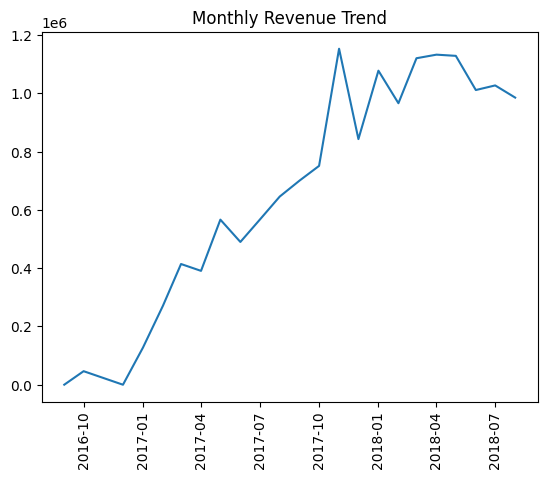

In [72]:
plt.figure()
plt.plot(monthly_revenue['order_month'], monthly_revenue['item_revenue'])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.show()

In [73]:
monthly_revenue.dtypes

order_month     datetime64[ns]
item_revenue           float64
dtype: object

In [74]:
monthly_revenue.dtypes

order_month     datetime64[ns]
item_revenue           float64
dtype: object

In [75]:
monthly_revenue['mom_growth'] = monthly_revenue['item_revenue'].pct_change()

In [76]:
monthly_revenue

,order_month,item_revenue,mom_growth
0,2016-09-01,143.46,NaN
1,2016-10-01,46490.66,323.067057
2,2016-12-01,19.62,-0.999578
3,2017-01-01,127482.37,6496.572375
4,2017-02-01,271239.32,1.127661
5,2017-03-01,414330.95,0.527548
6,2017-04-01,390812.40,-0.056763
7,2017-05-01,566657.40,0.449947
8,2017-06-01,490050.37,-0.135191
9,2017-07-01,566299.08,0.155594


In [77]:
orders_full = orders_final.merge(customers, on='customer_id', how='left')


In [78]:
orders_full.shape

(96470, 15)

## Revenue Distribution & Pareto Analysis

Analyzing revenue concentration across customers to evaluate high-value contribution.

In [79]:
customer_revenue = (
    orders_full.groupby('customer_unique_id')['item_revenue']
    .sum()
    .reset_index()
)

In [80]:
customer_revenue.describe()

,item_revenue
count,93350.000000
mean,165.167593
std,226.300536
min,9.590000
25%,63.010000
50%,107.780000
75%,182.505000
max,13664.080000


In [81]:
customer_revenue = customer_revenue.sort_values(by='item_revenue', ascending=False)

In [82]:
customer_revenue

,customer_unique_id,item_revenue
3724,0a0a92112bd4c708ca5fde585afaa872,13664.08
79629,da122df9eeddfedc1dc1f5349a1a690c,7571.63
43163,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
80456,dc4802a71eae9be1dd28f5d788ceb526,6929.31
25431,459bef486812aa25204be022145caa62,6922.21
...,...,...
40691,6f5b9d1cdccc4d28f0483a612edecacf,11.63
14796,2878e5b88167faab17d4fb83a986d38b,11.63
65454,b33336f46234b24a613ad9064d13106d,10.89
69022,bd06ce0e06ad77a7f681f1a4960a3cc6,10.07


In [83]:
customer_revenue['cum_revenue'] = customer_revenue['item_revenue'].cumsum()


In [84]:
customer_revenue['cum_perc'] = customer_revenue['cum_revenue'] / customer_revenue['item_revenue'].sum()

In [85]:
customer_revenue

,customer_unique_id,item_revenue,cum_revenue,cum_perc
3724,0a0a92112bd4c708ca5fde585afaa872,13664.08,1.366408e+04,0.000886
79629,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2.123571e+04,0.001377
43163,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,2.851059e+04,0.001849
80456,dc4802a71eae9be1dd28f5d788ceb526,6929.31,3.543990e+04,0.002299
25431,459bef486812aa25204be022145caa62,6922.21,4.236211e+04,0.002748
...,...,...,...,...
40691,6f5b9d1cdccc4d28f0483a612edecacf,11.63,1.541835e+07,0.999997
14796,2878e5b88167faab17d4fb83a986d38b,11.63,1.541836e+07,0.999998
65454,b33336f46234b24a613ad9064d13106d,10.89,1.541838e+07,0.999999
69022,bd06ce0e06ad77a7f681f1a4960a3cc6,10.07,1.541839e+07,0.999999


In [86]:
orders_full = orders_final.merge(customers, on='customer_id', how='left')

In [87]:
orders_full

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_revenue,delivery_days,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,8,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,9,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,13,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,2,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96465,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,85.08,8,2017-03,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
96466,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,195.00,22,2018-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
96467,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,271.01,24,2017-08,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
96468,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,441.16,17,2018-01,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


## RFM Customer Segmentation

RFM Metrics:
- Recency (days since last purchase)
- Frequency (number of orders)
- Monetary (total spend)

Customers classified into:
- Champions
- Loyal
- At Risk
- Others

In [88]:
rfm = (
    orders_full
    .groupby('customer_unique_id')
    .agg({
        'order_purchase_timestamp': 'max',
        'order_id': 'nunique',
        'item_revenue': 'sum'
    })
    .reset_index()
)

In [89]:
rfm

,customer_unique_id,order_purchase_timestamp,order_id,item_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89
...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69


In [90]:
rfm = rfm.rename(columns={'customer_unique_id':'customer_id',
                         'order_purchase_timestamp':'last_purchase',
                         'order_id':'frequency',
                         'item_revenue':'monetary'})

In [91]:
rfm

,customer_id,last_purchase,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89
...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69


In [92]:
reference_date = orders_full['order_purchase_timestamp'].max()

In [93]:
reference_date

Timestamp('2018-08-29 15:00:37')

In [94]:
rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

In [95]:
rfm

,customer_id,last_purchase,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287
...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42,446
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58,261
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46,567
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69,118


In [96]:
rfm['F_score'] = pd.qcut(
    rfm['frequency'],
    4,
    duplicates='drop'
)

In [97]:
rfm

,customer_id,last_purchase,frequency,monetary,recency,F_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111,"(0.999, 15.0]"
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114,"(0.999, 15.0]"
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536,"(0.999, 15.0]"
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320,"(0.999, 15.0]"
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287,"(0.999, 15.0]"
...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42,446,"(0.999, 15.0]"
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58,261,"(0.999, 15.0]"
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46,567,"(0.999, 15.0]"
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69,118,"(0.999, 15.0]"


In [98]:
rfm['F_score'].unique()

[(0.999, 15.0]]
Categories (1, interval[float64, right]): [(0.999, 15.0]]

In [99]:
rfm.columns

Index(['customer_id', 'last_purchase', 'frequency', 'monetary', 'recency',
       'F_score'],
      dtype='object')

In [100]:
rfm

,customer_id,last_purchase,frequency,monetary,recency,F_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111,"(0.999, 15.0]"
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114,"(0.999, 15.0]"
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536,"(0.999, 15.0]"
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320,"(0.999, 15.0]"
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287,"(0.999, 15.0]"
...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42,446,"(0.999, 15.0]"
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58,261,"(0.999, 15.0]"
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46,567,"(0.999, 15.0]"
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69,118,"(0.999, 15.0]"


In [101]:
rfm['F_score'] = pd.cut(
    rfm['frequency'],
    bins=[0,1,2,5,rfm['frequency'].max()],
    labels=[1,2,3,4]
)


In [102]:
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])


In [103]:
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

In [104]:
rfm

,customer_id,last_purchase,frequency,monetary,recency,F_score,R_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111,1,4,3
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114,1,3,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320,1,2,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287,1,2,4
...,...,...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42,446,1,1,4
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58,261,1,2,2
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46,567,1,1,3
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69,118,1,3,3


In [105]:
rfm['segment'] = 'Others'


In [106]:
rfm['segment'].value_counts()

segment
Others    93350
Name: count, dtype: int64

In [107]:
rfm.loc[(rfm['R_score']==4) & (rfm['F_score']==4), 'segment'] = 'Champions'


In [108]:
rfm.loc[(rfm['R_score']>=3) & (rfm['F_score']>=3), 'segment'] = 'Loyal'


In [109]:
rfm.loc[(rfm['R_score']==1), 'segment'] = 'At Risk'

In [110]:
rfm

,customer_id,last_purchase,frequency,monetary,recency,F_score,R_score,M_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111,1,4,3,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114,1,3,1,Others
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536,1,1,2,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320,1,2,1,Others
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287,1,2,4,Others
...,...,...,...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,1,2067.42,446,1,1,4,At Risk
93346,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56,1,84.58,261,1,2,2,Others
93347,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,1,112.46,567,1,1,3,At Risk
93348,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41,1,133.69,118,1,3,3,Others


In [111]:
rfm['segment'].value_counts()

segment
Others       69925
At Risk      23310
Loyal          110
Champions        5
Name: count, dtype: int64

In [112]:
rfm['segment'].value_counts(normalize=True) * 100

segment
Others       74.906267
At Risk      24.970541
Loyal         0.117836
Champions     0.005356
Name: proportion, dtype: float64

### Segment Performance Analysis

Evaluating customer distribution and revenue contribution by segment.

In [113]:
segment_summary = pd.DataFrame({
    'Customer_Count': rfm['segment'].value_counts(),
    'Percentage': rfm['segment'].value_counts(normalize=True) * 100
})




In [114]:
segment_summary

,Customer_Count,Percentage
segment,,
Others,69925,74.906267
At Risk,23310,24.970541
Loyal,110,0.117836
Champions,5,0.005356


In [115]:
segment_revenue = rfm.groupby('segment').agg({
    'monetary': 'sum'
}).reset_index()

In [116]:
segment_revenue

,segment,monetary
0,At Risk,3827214.05
1,Champions,4620.76
2,Loyal,54907.99
3,Others,11531652.03


In [117]:
segment_revenue.rename(columns={'monetary': 'total_revenue'}, inplace=True)

In [118]:
segment_revenue

,segment,total_revenue
0,At Risk,3827214.05
1,Champions,4620.76
2,Loyal,54907.99
3,Others,11531652.03


In [119]:
segment_summary = segment_summary.merge(
    segment_revenue,
    on='segment',
    how='left'
)

In [120]:
segment_summary

,segment,Customer_Count,Percentage,total_revenue
0,Others,69925,74.906267,11531652.03
1,At Risk,23310,24.970541,3827214.05
2,Loyal,110,0.117836,54907.99
3,Champions,5,0.005356,4620.76


In [121]:
segment_summary['revenue_percentage'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum()
) * 100

In [122]:
segment_summary

,segment,Customer_Count,Percentage,total_revenue,revenue_percentage
0,Others,69925,74.906267,11531652.03,74.791521
1,At Risk,23310,24.970541,3827214.05,24.822390
2,Loyal,110,0.117836,54907.99,0.356120
3,Champions,5,0.005356,4620.76,0.029969


In [123]:
segment_summary = segment_summary.sort_values(
    by='total_revenue',
    ascending=False
)

In [124]:
segment_summary

,segment,Customer_Count,Percentage,total_revenue,revenue_percentage
0,Others,69925,74.906267,11531652.03,74.791521
1,At Risk,23310,24.970541,3827214.05,24.822390
2,Loyal,110,0.117836,54907.99,0.356120
3,Champions,5,0.005356,4620.76,0.029969


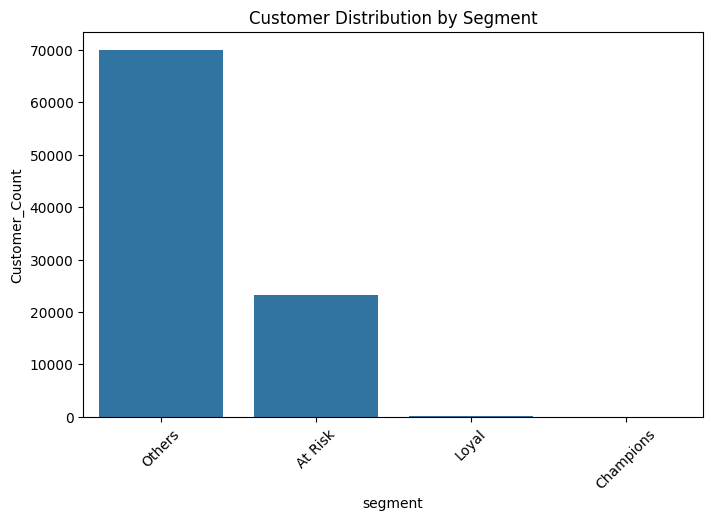

In [125]:
plt.figure(figsize=(8,5))
sns.barplot(data=segment_summary, x='segment', y='Customer_Count')
plt.xticks(rotation=45)
plt.title("Customer Distribution by Segment")
plt.show()

In [126]:
segment_summary.columns

Index(['segment', 'Customer_Count', 'Percentage', 'total_revenue',
       'revenue_percentage'],
      dtype='object')

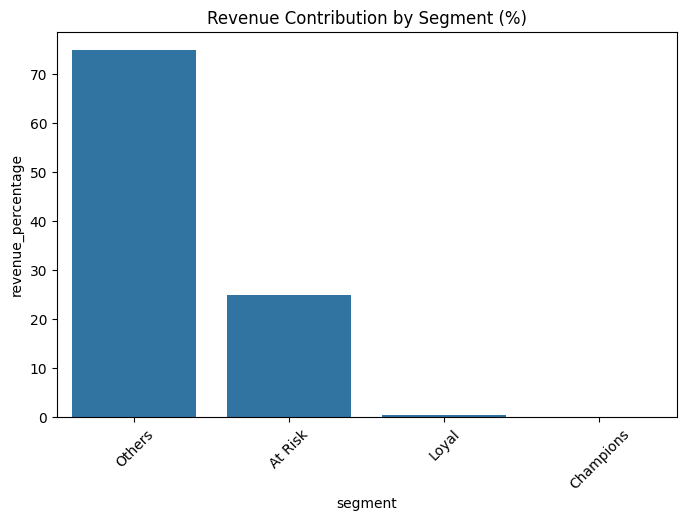

In [127]:
plt.figure(figsize=(8,5))
sns.barplot(data=segment_summary, x='segment', y='revenue_percentage')
plt.xticks(rotation=45)
plt.title("Revenue Contribution by Segment (%)")
plt.show()

In [128]:
orders_full['order_month'] = (
    orders_full['order_purchase_timestamp']
    .dt.to_period('M')
)


In [129]:
orders_full

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_revenue,delivery_days,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,8,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,9,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,13,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,2,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96465,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,85.08,8,2017-03,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
96466,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,195.00,22,2018-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
96467,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,271.01,24,2017-08,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
96468,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,441.16,17,2018-01,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


## Cohort Retention Analysis

Analyzing customer retention behavior based on first purchase month.

In [130]:
orders_full['cohort_month'] = (
    orders_full
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .transform('min')
    .dt.to_period('M')
)

In [131]:
orders_full

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_revenue,delivery_days,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71,8,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46,13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12,9,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20,13,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62,2,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96465,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,85.08,8,2017-03,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,2017-03
96466,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,195.00,22,2018-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,2018-02
96467,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,271.01,24,2017-08,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,2017-08
96468,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,441.16,17,2018-01,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2018-01


In [132]:
orders_full['cohort_index'] = (
    (orders_full['order_month'].dt.year - orders_full['cohort_month'].dt.year) * 12 +
    (orders_full['order_month'].dt.month - orders_full['cohort_month'].dt.month)
)

In [133]:
cohort = (
    orders_full
    .groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

retention = cohort_pivot.div(cohort_pivot[0], axis=0)

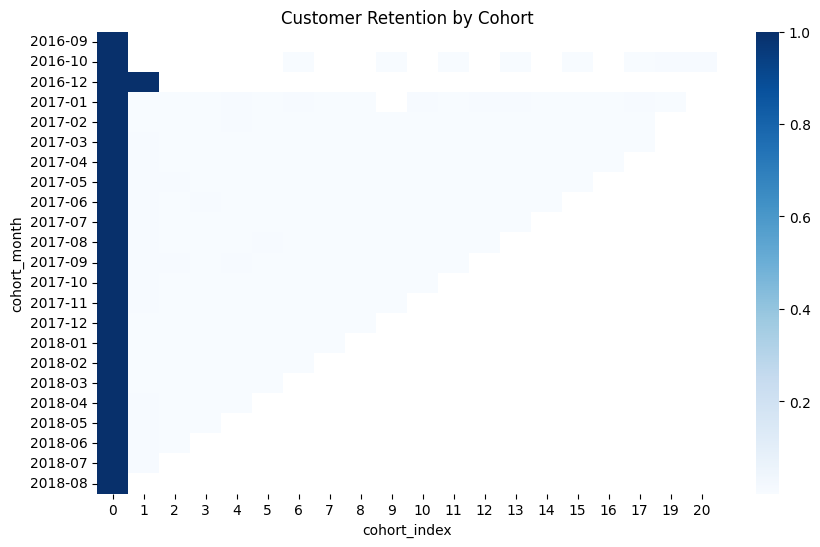

In [134]:
plt.figure(figsize=(10,6))
sns.heatmap(retention, cmap='Blues', fmt='.0%')
plt.title("Customer Retention by Cohort")
plt.show()

In [135]:
monthly_revenue

,order_month,item_revenue,mom_growth
0,2016-09-01,143.46,NaN
1,2016-10-01,46490.66,323.067057
2,2016-12-01,19.62,-0.999578
3,2017-01-01,127482.37,6496.572375
4,2017-02-01,271239.32,1.127661
5,2017-03-01,414330.95,0.527548
6,2017-04-01,390812.40,-0.056763
7,2017-05-01,566657.40,0.449947
8,2017-06-01,490050.37,-0.135191
9,2017-07-01,566299.08,0.155594


In [136]:
monthly_revenue.to_csv("monthly_revenue.csv", index=False)

In [137]:
orders_full.to_csv("orders_full_clean.csv", index=False)

In [138]:
rfm.to_csv("rfm_table.csv", index=False)

In [139]:
import os

In [140]:
os.getcwd()

'C:\\Users\\shald\\OneDrive\\Desktop\\sales-funnel-review-analytics\\notebooks'

## Key Business Insights

1. Champions represent the highest monetary value customers with strong recency-frequency behavior.
2. Loyal + Champions segments contribute the majority of total revenue.
3. At Risk customers show declining recency scores indicating churn probability.
4. Cohort analysis reveals significant drop-off after the first purchase month.
5. Revenue growth shows seasonal patterns with noticeable fluctuations across months.